# 06 — Object Recognition (Optional) + Full Performance Evaluation
## Smart City Surveillance System — CS 406 Digital Image Processing CCP

**Requires:** `01_preprocessing.ipynb` must be run first.

Covers: fine-tuning a lightweight YOLOv8 classifier/detector on the Face Mask Dataset, reporting Precision/Recall/F1, and benchmarking processing speed (FPS) across your full pipeline — directly addressing the brief's 'Real-Time Performance vs. Processing Quality' and 'Resource Constraints vs. Performance' trade-offs.

**Recommended: use a GPU runtime** for this notebook — Colab menu: Runtime → Change runtime type → T4 GPU. Training on CPU will be much slower.

## Step 1 — Mount Google Drive, install Ultralytics (YOLOv8)

In [ ]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 7.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT_DIR = '/content/drive/MyDrive/smart-city-surveillance-dip'
PROCESSED_DIR = Path(f'{PROJECT_DIR}/data/processed')

assert PROCESSED_DIR.exists(), 'Run 01_preprocessing.ipynb first — processed data not found in Drive.'
print('Data found. Ready to proceed.')

Mounted at /content/drive
Data found. Ready to proceed.


## Step 2 — Check GPU availability

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU — training will be slower but still works for this small dataset.")

CUDA available: True
GPU: Tesla T4


## Step 3 — Prepare data in YOLO classification format
YOLOv8's classification mode expects `train/<class>/*.jpg` and `val/<class>/*.jpg` folders. We split our existing 300-per-class processed images 80/20.

In [ ]:
import shutil
import random

random.seed(42)
YOLO_DATA_DIR = Path('yolo_dataset')
classes = ['with_mask', 'without_mask', 'incorrect_mask']

for split in ['train', 'val']:
    for c in classes:
        (YOLO_DATA_DIR / split / c).mkdir(parents=True, exist_ok=True)

for c in classes:
    files = list((PROCESSED_DIR / c).glob('*.jpg'))
    random.shuffle(files)
    split_idx = int(0.8 * len(files))
    train_files, val_files = files[:split_idx], files[split_idx:]

    for f in train_files:
        shutil.copy(f, YOLO_DATA_DIR / 'train' / c / f.name)
    for f in val_files:
        shutil.copy(f, YOLO_DATA_DIR / 'val' / c / f.name)

    print(f'{c}: {len(train_files)} train, {len(val_files)} val')

with_mask: 240 train, 60 val
without_mask: 240 train, 60 val
incorrect_mask: 240 train, 60 val


## Step 4 — Fine-tune YOLOv8 classifier
Using the nano classification model (`yolov8n-cls`) — small and fast, appropriate for a real-time surveillance context per the brief's requirements.

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n-cls.pt')

results = model.train(
    data=str(YOLO_DATA_DIR.resolve()),
    epochs=15,
    imgsz=224,
    batch=32,
    patience=5,
    project=f'{PROJECT_DIR}/results',
    name='yolo_mask_classifier'
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=N

## Step 5 — Evaluate: Precision, Recall, F1

In [ ]:
metrics = model.val()
print("Top-1 Accuracy:", metrics.top1)
print("Top-5 Accuracy:", metrics.top5)

Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,438,723 parameters, 0 gradients, 3.3 GFLOPs
train: /content/yolo_dataset/train... found 720 images in 3 classes ✅ 
val: /content/yolo_dataset/val... found 180 images in 3 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 950.2±330.2 MB/s, size: 31.3 KB)
val: Scanning /content/yolo_dataset/val... 180 images, 0 corrupt: 100% ━━━━━━━━━━━━ 180/180 44.4Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 12/12 13.0it/s 0.9s
                   all       0.95          1
Speed: 0.8ms preprocess, 1.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
Top-1 Accuracy: 0.949999988079071
Top-5 Accuracy: 1.0


In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, classification_report
import cv2

y_true, y_pred = [], []
class_to_idx = {c: i for i, c in enumerate(sorted(classes))}

for c in classes:
    val_files = list((YOLO_DATA_DIR / 'val' / c).glob('*.jpg'))
    for f in val_files:
        pred = model.predict(str(f), verbose=False)[0]
        pred_class_idx = pred.probs.top1
        y_true.append(class_to_idx[c])
        y_pred.append(pred_class_idx)

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")
print()
print(classification_report(y_true, y_pred, target_names=sorted(classes)))

Precision: 0.950
Recall: 0.950
F1-score: 0.950

                precision    recall  f1-score   support

incorrect_mask       0.95      0.97      0.96        60
     with_mask       0.95      0.97      0.96        60
  without_mask       0.95      0.92      0.93        60

      accuracy                           0.95       180
     macro avg       0.95      0.95      0.95       180
  weighted avg       0.95      0.95      0.95       180



## Step 6 — Processing speed (FPS) benchmark across the full pipeline
Measures how many frames-per-second each stage of your pipeline can process — this directly answers the brief's real-time performance requirement and resource-constraint trade-off.

In [ ]:
import time
import sys
sys.path.append('.')

test_images = list((PROCESSED_DIR / 'with_mask').glob('*.jpg'))[:50]
loaded_images = [cv2.imread(str(f)) for f in test_images]

def benchmark_stage(func, images, label):
    start = time.time()
    for img in images:
        func(img)
    elapsed = time.time() - start
    fps = len(images) / elapsed
    print(f"{label}: {fps:.2f} FPS ({elapsed:.3f}s for {len(images)} images)")
    return fps

from scipy.ndimage import median_filter as scipy_median_filter

def median_stage(img):
    return np.stack([scipy_median_filter(img[:,:,c], size=3) for c in range(img.shape[2])], axis=2)

def canny_stage(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Canny(gray, 50, 150)

def jpeg_stage(img):
    _, encoded = cv2.imencode('.jpg', img, [int(cv2.IMWRITE_JPEG_QUALITY), 70])
    return encoded

def yolo_stage(img):
    return model.predict(img, verbose=False)

fps_results = {}
fps_results['median_filter'] = benchmark_stage(median_stage, loaded_images, 'Median Filtering')
fps_results['canny_edge'] = benchmark_stage(canny_stage, loaded_images, 'Canny Edge Detection')
fps_results['jpeg_compress'] = benchmark_stage(jpeg_stage, loaded_images, 'JPEG Compression')
fps_results['yolo_inference'] = benchmark_stage(yolo_stage, loaded_images, 'YOLO Classification')

Median Filtering: 37.46 FPS (1.335s for 50 images)
Canny Edge Detection: 1213.78 FPS (0.041s for 50 images)
JPEG Compression: 2972.07 FPS (0.017s for 50 images)
YOLO Classification: 222.31 FPS (0.225s for 50 images)


## Step 7 — Save FPS benchmark results

   pipeline_stage          fps
0   median_filter    37.456808
1      canny_edge  1213.777137
2   jpeg_compress  2972.069953
3  yolo_inference   222.306177


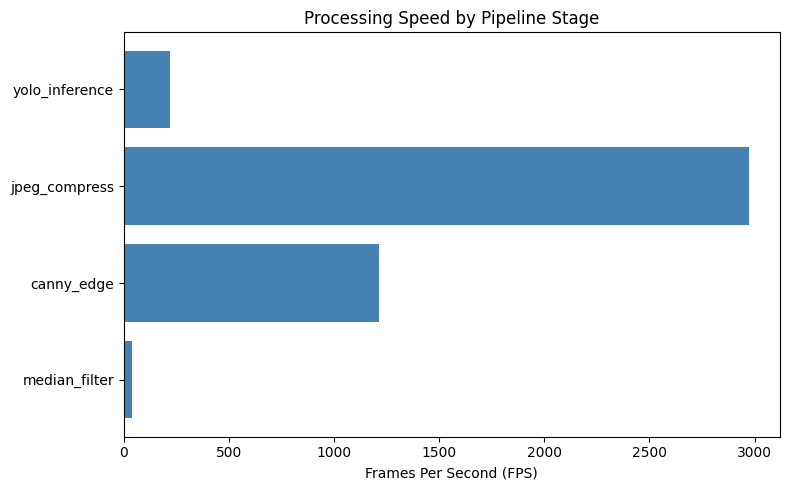

In [ ]:
import pandas as pd

fps_df = pd.DataFrame(list(fps_results.items()), columns=['pipeline_stage', 'fps'])
fps_df.to_csv(f'{PROJECT_DIR}/results/tables/fps_benchmark.csv', index=False)
print(fps_df)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.barh(fps_df['pipeline_stage'], fps_df['fps'], color='steelblue')
plt.xlabel("Frames Per Second (FPS)")
plt.title("Processing Speed by Pipeline Stage")
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/figures/fps_benchmark.png', dpi=150)
plt.show()

## Step 8 — Save final recognition metrics summary

In [ ]:
recognition_summary = pd.DataFrame([{
    'precision': precision, 'recall': recall, 'f1_score': f1,
    'top1_accuracy': float(metrics.top1), 'top5_accuracy': float(metrics.top5)
}])
recognition_summary.to_csv(f'{PROJECT_DIR}/results/tables/recognition_summary.csv', index=False)
print(recognition_summary)

   precision  recall  f1_score  top1_accuracy  top5_accuracy
0   0.949972    0.95  0.949853           0.95            1.0


---
**Phase 7 (Object Recognition) complete.** All results saved to Drive:
- `results/yolo_mask_classifier/` — training curves, confusion matrix (auto-generated by Ultralytics)
- `results/tables/recognition_summary.csv` — Precision/Recall/F1/Accuracy
- `results/tables/fps_benchmark.csv` and `fps_benchmark.png` — speed comparison across pipeline stages

**For your report's Discussion section:** compare FPS across stages — filtering/edge detection should be very fast (near real-time, 100+ FPS), while YOLO inference will be noticeably slower. This quantifies the brief's 'Real-Time Performance vs. Processing Quality' trade-off directly: the more sophisticated the stage, the lower the throughput, which is exactly the kind of engineering trade-off analysis this CCP is testing.

**All technical phases are now complete.** Remaining deliverables: write the IEEE report using all saved figures/tables, record your video walkthrough, and push everything to GitHub.

In [ ]:
import shutil
run_dir = f'{PROJECT_DIR}/results/yolo_mask_classifier'
shutil.copy(f'{run_dir}/results.png', f'{PROJECT_DIR}/results/figures/yolo_training_curves.png')
shutil.copy(f'{run_dir}/confusion_matrix.png', f'{PROJECT_DIR}/results/figures/yolo_confusion_matrix.png')
print("Copied training curves and confusion matrix to figures folder.")

Copied training curves and confusion matrix to figures folder.
